# KV cache simulation — plots

Reads `../results/results_<dataset>.csv` written by `run_one.py` (or `run_all.py`).
The `DATASET` variable below (or env `KV_SIM_PLOT_DATASET`) must match `--dataset` used when running experiments.

All three plots (page size, eviction, ordering) load from the same unified CSV and filter by the relevant columns.
Use the commented-out `.query(...)` lines in each cell to narrow the data if needed.

In [31]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
RES = ROOT / "results"

# Match `experiments/*.py --dataset` (or set env KV_SIM_PLOT_DATASET)
DATASET = os.environ.get("KV_SIM_PLOT_DATASET", "loogle")
# DATASET = 'narrativeqa'
DATASET = 'sharegpt_90k_raw'
DATASET = 'swesmith'

ORDERING = "random"  # original | min_distance | max_distance | random

# Color families per strategy — used across all plots
_STRAT_CMAP_NAMES = ["Blues", "Reds", "Greens", "Purples", "Oranges"]

In [32]:
def load_results_csv(dataset: str | None = None) -> pd.DataFrame | None:
    """Load ``results_{dataset}.csv`` written by run_one.py."""
    dataset = dataset or DATASET
    p = RES / f"results_{dataset}.csv"
    if not p.is_file():
        print(f"Missing {p}")
        return None
    return pd.read_csv(p)

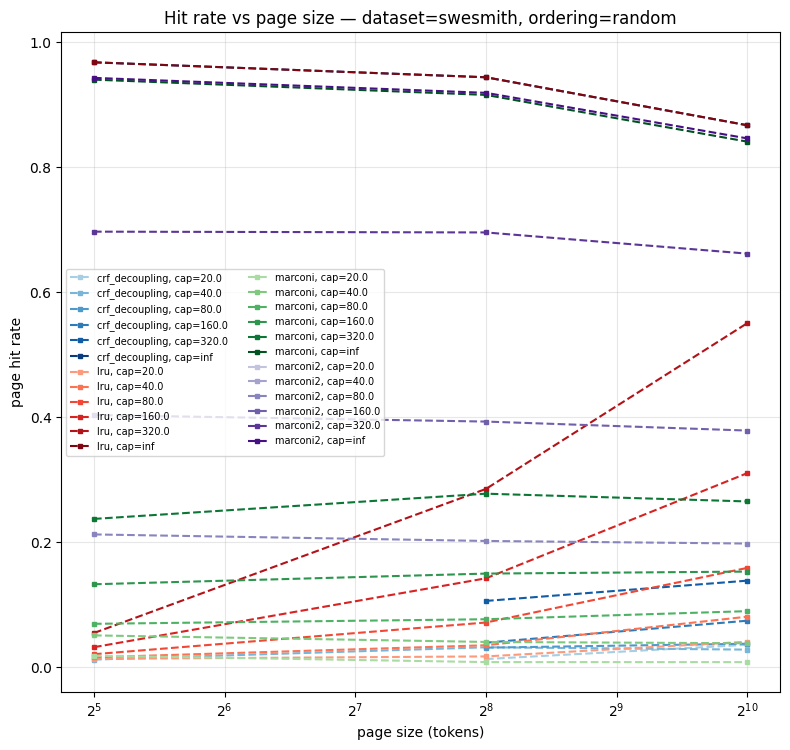

In [33]:
df_ps = load_results_csv()
if df_ps is not None and len(df_ps):
    df_ps = df_ps.copy()
    df_ps["page_size"] = pd.to_numeric(df_ps["page_size"], errors="coerce")
    df_ps = df_ps[df_ps["ordering"] == ORDERING]
    df_ps = df_ps.dropna(subset=["page_size"]).sort_values("page_size")

    ds_list = sorted(df_ps["dataset"].dropna().unique())
    if not ds_list:
        print("No 'dataset' column values to plot.")
    else:
        fig, axes = plt.subplots(
            len(ds_list), 1, figsize=(8, max(3.5*2, 2*3.8 * len(ds_list))), squeeze=False
        )
        for ax, ds in zip(axes.ravel(), ds_list):
            sub = df_ps[df_ps["dataset"] == ds]
            strategies = sorted(sub["strategy"].dropna().unique())
            strat_cmaps = {s: plt.get_cmap(_STRAT_CMAP_NAMES[i % len(_STRAT_CMAP_NAMES)])
                           for i, s in enumerate(strategies)}
            capacity = sorted(sub["capacity_spec"].dropna().unique(),
                              key=lambda c: float("inf") if c == "inf" else float(c))
            cap_pos = {c: v for c, v in zip(capacity, np.linspace(0.35, 0.95, len(capacity)))}
            for strat in strategies:
                for cap in capacity:
                    # if cap not in ["inf", float("inf"), 40, 160]:
                    #     continue
                    g = sub[(sub["strategy"] == strat) & (sub["capacity_spec"] == cap)].sort_values("page_size")
                    ax.plot(
                        g["page_size"],
                        g["page_level_hit_rate"],
                        "s--",
                        color=strat_cmaps[strat](cap_pos[cap]),
                        label=f"{strat}, cap={cap}",
                        ms=3,
                    )
            ax.set_xscale("log", base=2)
            ax.set_xlabel("page size (tokens)")
            ax.set_ylabel("page hit rate")
            ax.legend(loc="best", fontsize=7, ncol=2)
            ax.set_title(f"Hit rate vs page size — dataset={ds}, ordering={ORDERING}")
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

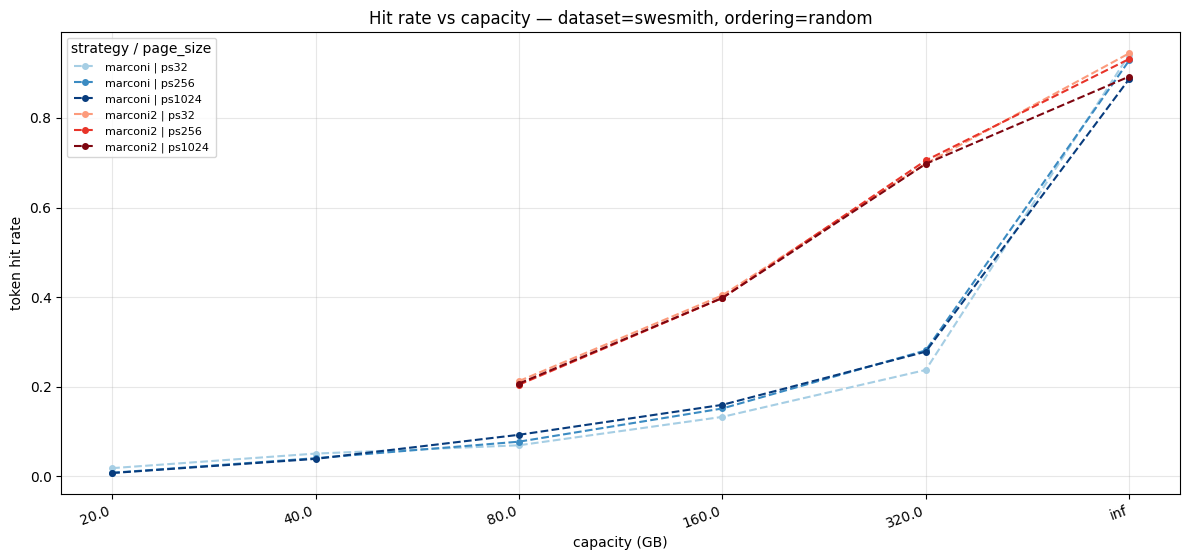

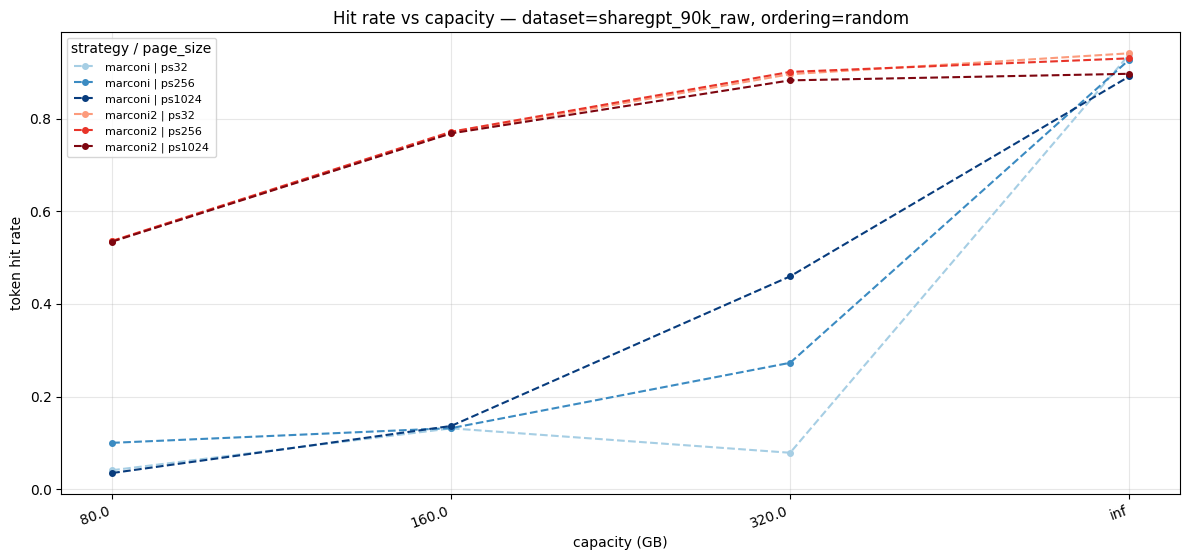

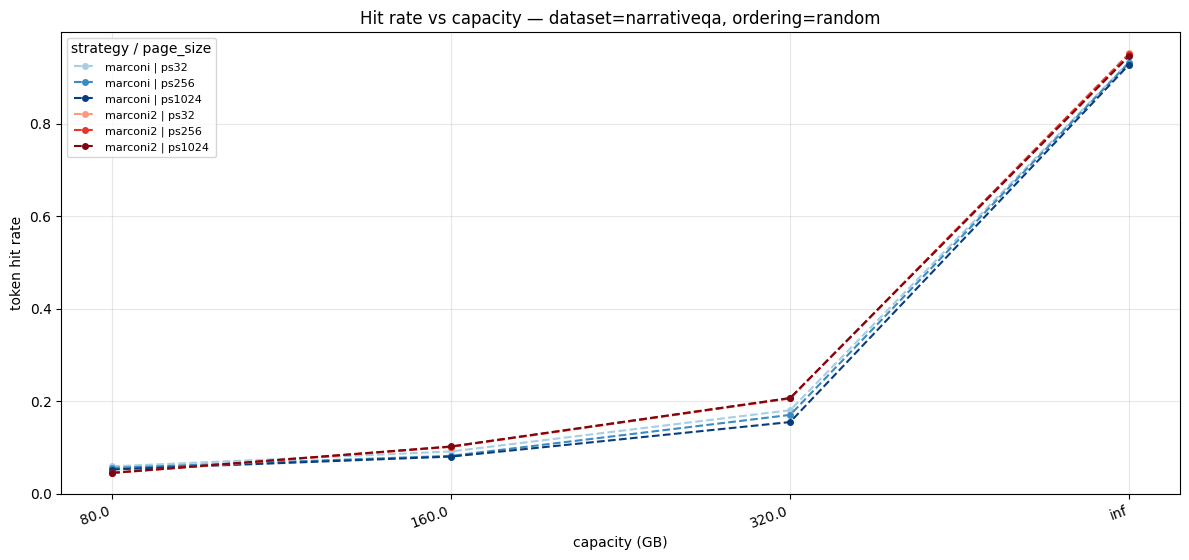

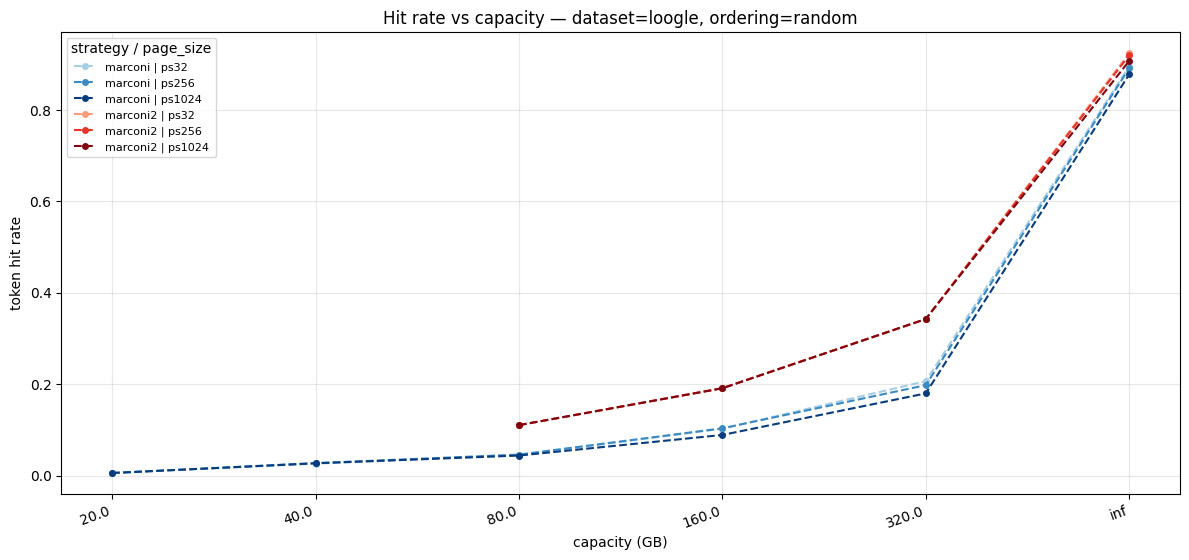

In [34]:
def _capacity_rank(s) -> float:
    t = str(s).lower().replace("gb", "").strip()
    if t in ("inf", "none", "unlimited", "nan"):
        return float("inf")
    try:
        return float(t)
    except ValueError:
        return float("nan")


def plot_hit_rate_vs_capacity(
    df: pd.DataFrame,
    page_sizes: list | None = None,
    strategies: list | None = None,
    ordering: str | None = None,
):
    if df is None or not len(df):
        print("No data to plot.")
        return

    data = df.copy()
    data["page_size"] = pd.to_numeric(data["page_size"], errors="coerce")
    data["_cap_r"] = data["capacity_spec"].map(_capacity_rank)

    if page_sizes:
        data = data[data["page_size"].isin(page_sizes)]
    if strategies:
        data = data[data["strategy"].isin(strategies)]
    if ordering:
        data = data[data["ordering"] == ordering]

    ds_list = sorted(data["dataset"].dropna().unique())
    if not ds_list:
        print("No rows left after filtering.")
        return

    fig, axes = plt.subplots(
        len(ds_list), 1, figsize=(12, max(1.5* 3.5, 1.5* 3.8 * len(ds_list))), squeeze=False
    )

    for ax, ds in zip(axes.ravel(), ds_list):
        sub = data[data["dataset"] == ds]
        caps_df = sub.drop_duplicates("capacity_spec").sort_values("_cap_r")
        xlabels = [str(x) for x in caps_df["capacity_spec"]]
        xpos = {lab: i for i, lab in enumerate(xlabels)}

        all_strategies = sorted(sub["strategy"].dropna().unique())
        strat_cmaps = {s: plt.get_cmap(_STRAT_CMAP_NAMES[i % len(_STRAT_CMAP_NAMES)])
                       for i, s in enumerate(all_strategies)}
        all_ps = sorted(sub["page_size"].dropna().unique())
        ps_pos = {ps: v for ps, v in zip(all_ps, np.linspace(0.35, 0.95, len(all_ps)))}

        groups = (
            sub.dropna(subset=["strategy", "page_size"])
            .groupby(["strategy", "page_size"], dropna=False)
        )

        for (strat, ps), g in groups:
            g = g.sort_values("_cap_r")
            xs = [xpos[str(cs)] for cs in g["capacity_spec"]]
            c = strat_cmaps[strat](ps_pos[ps])
            label = f"{strat} | ps{int(ps)}"
            ax.plot(xs, g["token_level_hit_rate"], "o--", color=c, label=label, ms=4)

        ax.set_xticks(range(len(xlabels)))
        ax.set_xticklabels(xlabels, rotation=20, ha="right")
        ax.set_xlabel("capacity (GB)")
        ax.set_ylabel("token hit rate")
        ax.legend(title="strategy / page_size", fontsize=8)
        title = f"Hit rate vs capacity — dataset={ds}"
        if ordering:
            title += f", ordering={ordering}"
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

strategies = ['marconi', 'marconi2']
page_sizes=[32, 256, 1024]
df_cap = load_results_csv(DATASET)
plot_hit_rate_vs_capacity(
    df_cap,
    page_sizes=page_sizes,
    strategies=strategies,
    ordering=ORDERING,
)
df_cap = load_results_csv("sharegpt_90k_raw")
plot_hit_rate_vs_capacity(
    df_cap,
    page_sizes=page_sizes,
    strategies=strategies,
    ordering=ORDERING,
)
df_cap = load_results_csv("narrativeqa")
plot_hit_rate_vs_capacity(
    df_cap,
    page_sizes=page_sizes,
    strategies=strategies,
    ordering=ORDERING,
)
df_cap = load_results_csv("loogle")
plot_hit_rate_vs_capacity(
    df_cap,
    page_sizes=page_sizes,
    strategies=strategies,
    ordering=ORDERING,
)

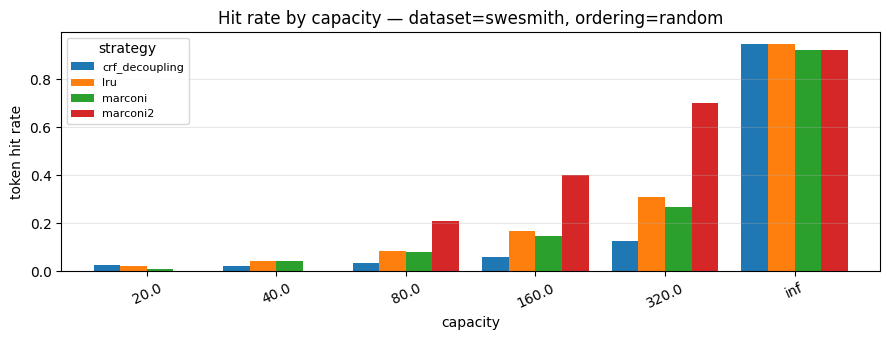

In [35]:
df_ord = load_results_csv()
if df_ord is not None and len(df_ord):
    df_ord = df_ord[df_ord["ordering"] == ORDERING]
    ds_list = sorted(df_ord["dataset"].dropna().unique())
    fig, axes = plt.subplots(
        len(ds_list), 1, figsize=(9, max(3.2, 3.5 * len(ds_list))), squeeze=False
    )
    for ax, ds in zip(axes.ravel(), ds_list):
        sub = df_ord[df_ord["dataset"] == ds]
        pivot = sub.pivot_table(
            index="capacity_spec",
            columns="strategy",
            values="token_level_hit_rate",
            aggfunc="mean",
        )
        pivot.plot(kind="bar", ax=ax, rot=25, width=0.82)
        ax.set_ylabel("token hit rate")
        ax.set_xlabel("capacity")
        ax.legend(title="strategy", fontsize=8)
        ax.set_title(f"Hit rate by capacity — dataset={ds}, ordering={ORDERING}")
        ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
# Load/compute ratio CDF: need per-request ratios from JSON (or re-run sim).
# Placeholder: CDF of per-request rates from a single detailed JSON if you export traces.
import json

json_dir = RES / f"json_{DATASET}"
if json_dir.is_dir():
    files = sorted(json_dir.glob("*.json"))
    if files:
        print("Example: inspect", files[0].name, "for future per-request CDF export.")

Example: inspect swesmith_ps1024_original_lru_cap160.json for future per-request CDF export.
